# Hospital Data Analysis Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [2]:
appointments = pd.read_csv('appointments.csv')
departments = pd.read_csv('departments.csv')
doctors = pd.read_csv('doctors.csv')
medical_records = pd.read_csv('medical_records.csv')
patients = pd.read_csv('patients.csv')

In [3]:
appointments.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,status,visit_type,fee_paid
0,1,337,3,2022-06-26,16:15,Completed,Routine Check,150
1,2,251,48,2024-09-15,12:00,Completed,Follow-up,250
2,3,270,10,2022-09-22,10:30,Scheduled,Routine Check,300
3,4,320,32,2022-12-21,10:30,Completed,Follow-up,300
4,5,360,42,2023-02-13,08:15,No-Show,Emergency,400


In [4]:
patients.head()

,patient_id,first_name,last_name,date_of_birth,gender,blood_group,city,phone,insurance,registration_date,Full Name
0,1,Mona,Saber,2005-03-05,Female,AB+,Alexandria,1284371711,Yes,2024-03-04,Mona Saber
1,2,Hana,Soliman,2003-04-19,Female,AB+,Luxor,1282494408,Yes,2021-11-16,Hana Soliman
2,3,Nadia,Saber,1995-06-29,Female,A+,Suez,1198663948,No,2021-06-16,Nadia Saber
3,4,Ali,Nour,1984-06-29,Male,O+,Port Said,1149916439,Yes,2022-01-09,Ali Nour
4,5,Ahmed,Ramadan,1991-07-07,Male,B+,Alexandria,1022873617,Yes,2022-01-07,Ahmed Ramadan


In [5]:
doctors.head()

,doctor_id,first_name,last_name,department_id,years_experience,consultation_fee,available_days,full_name
0,1,Omar,Ramadan,7,23,250,Sat-Wed,Dr. Omar Ramadan
1,2,Ahmed,Soliman,10,17,400,Sat-Wed,Dr. Ahmed Soliman
2,3,Sara,Gaber,8,19,300,Sun-Thu,Dr. Sara Gaber
3,4,Youssef,Salem,9,7,200,Sun-Thu,Dr. Youssef Salem
4,5,Youssef,Zaki,5,10,350,Sat-Thu,Dr. Youssef Zaki


In [6]:
medical_records.head()

,record_id,appointment_id,diagnosis,medication,dosage,duration_days,notes,follow_up_required,outcome
0,1,562,Dermatitis,Sertraline,Three times daily,7,Follow-up in 2 weeks,No,Improving
1,2,1344,Coronary Artery Disease,Cetirizine,Three times daily,14,Patient responded well,Yes,Recovered
2,3,1565,Anemia,Lisinopril,Once daily,14,Dietary changes recommended,No,Critical
3,4,1424,Asthma,Metformin,Once daily,7,Follow-up in 2 weeks,No,Needs Follow-up
4,5,819,Anxiety Disorder,Atorvastatin,Twice daily,21,Rest advised,Yes,Needs Follow-up


In [7]:
departments.head()

,department_id,department_name,department_head,floor,phone_ext
0,1,Cardiology,Dr. Ahmed Saber,2,1000
1,2,Neurology,Dr. Mona Khalil,3,1001
2,3,Orthopedics,Dr. Tarek Nour,4,1002
3,4,Pediatrics,Dr. Sara Adel,1,1003
4,5,Oncology,Dr. Hani Zaki,5,1004


In [8]:
appointments.shape, patients.shape, doctors.shape, medical_records.shape, departments.shape

((2000, 8), (500, 11), (50, 8), (1294, 9), (10, 5))

In [9]:
appointments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   appointment_id    2000 non-null   int64 
 1   patient_id        2000 non-null   int64 
 2   doctor_id         2000 non-null   int64 
 3   appointment_date  2000 non-null   object
 4   appointment_time  2000 non-null   object
 5   status            2000 non-null   object
 6   visit_type        2000 non-null   object
 7   fee_paid          2000 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 125.1+ KB


In [10]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   patient_id         500 non-null    int64 
 1   first_name         500 non-null    object
 2   last_name          500 non-null    object
 3   date_of_birth      500 non-null    object
 4   gender             500 non-null    object
 5   blood_group        500 non-null    object
 6   city               500 non-null    object
 7   phone              500 non-null    int64 
 8   insurance          500 non-null    object
 9   registration_date  500 non-null    object
 10  Full Name          500 non-null    object
dtypes: int64(2), object(9)
memory usage: 43.1+ KB


In [11]:
appointments.isnull().sum()

appointment_id      0
patient_id          0
doctor_id           0
appointment_date    0
appointment_time    0
status              0
visit_type          0
fee_paid            0
dtype: int64

In [12]:
patients.isnull().sum()

patient_id           0
first_name           0
last_name            0
date_of_birth        0
gender               0
blood_group          0
city                 0
phone                0
insurance            0
registration_date    0
Full Name            0
dtype: int64

In [13]:
medical_records.isnull().sum()

record_id             0
appointment_id        0
diagnosis             0
medication            0
dosage                0
duration_days         0
notes                 0
follow_up_required    0
outcome               0
dtype: int64

In [14]:
appointments.describe()

,appointment_id,patient_id,doctor_id,fee_paid
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,250.666500,25.594500,233.025000
std,577.494589,141.971188,14.392068,124.572704
min,1.000000,1.000000,1.000000,0.000000
25%,500.750000,130.000000,13.000000,150.000000
50%,1000.500000,255.500000,26.000000,250.000000
75%,1500.250000,370.000000,38.000000,350.000000
max,2000.000000,500.000000,50.000000,400.000000


In [15]:
patients.describe(include='all')

,patient_id,first_name,last_name,date_of_birth,gender,blood_group,city,phone,insurance,registration_date,Full Name
count,500.000000,500,500,500,500,500,500,5.000000e+02,500,500,500
unique,NaN,16,16,498,2,8,10,NaN,2,442,224
top,NaN,Sara,Gaber,1959-03-16,Female,O+,Alexandria,NaN,Yes,2024-04-27,Hana Soliman
freq,NaN,40,41,2,266,75,58,NaN,253,3,6
mean,250.500000,NaN,NaN,NaN,NaN,NaN,NaN,1.158807e+09,NaN,NaN,NaN
std,144.481833,NaN,NaN,NaN,NaN,NaN,NaN,8.799091e+07,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.010553e+09,NaN,NaN,NaN
25%,125.750000,NaN,NaN,NaN,NaN,NaN,NaN,1.078634e+09,NaN,NaN,NaN
50%,250.500000,NaN,NaN,NaN,NaN,NaN,NaN,1.154452e+09,NaN,NaN,NaN
75%,375.250000,NaN,NaN,NaN,NaN,NaN,NaN,1.241902e+09,NaN,NaN,NaN


## Data Cleaning

In [16]:
apt = appointments.copy()
pat = patients.copy()
doc = doctors.copy()
med = medical_records.copy()
dept = departments.copy()

In [17]:
# rename columns to lowercase
for df in [apt, pat, doc, med, dept]:
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

In [18]:
# remove duplicates
apt.drop_duplicates(inplace=True)
pat.drop_duplicates(inplace=True)
doc.drop_duplicates(inplace=True)
med.drop_duplicates(inplace=True)

In [19]:
# clean text columns
apt['status'] = apt['status'].str.strip().str.title()
apt['visit_type'] = apt['visit_type'].str.strip().str.title()

pat['gender'] = pat['gender'].str.strip().str.title()
pat['city'] = pat['city'].str.strip().str.title()
pat['insurance'] = pat['insurance'].str.strip().str.title()
pat['blood_group'] = pat['blood_group'].str.strip()

med['diagnosis'] = med['diagnosis'].str.strip().str.title()
med['outcome'] = med['outcome'].str.strip().str.title()
med['follow_up_required'] = med['follow_up_required'].str.strip().str.title()

In [20]:
apt['status'].value_counts()

status
Completed    1294
Cancelled     317
No-Show       198
Scheduled     191
Name: count, dtype: int64

In [21]:
pat['gender'].value_counts()

gender
Female    266
Male      234
Name: count, dtype: int64

## Data Transformation

In [22]:
# convert date columns
apt['appointment_date'] = pd.to_datetime(apt['appointment_date'])
pat['date_of_birth'] = pd.to_datetime(pat['date_of_birth'])
pat['registration_date'] = pd.to_datetime(pat['registration_date'])

In [23]:
# extract date parts
apt['year'] = apt['appointment_date'].dt.year
apt['month'] = apt['appointment_date'].dt.month
apt['month_name'] = apt['appointment_date'].dt.strftime('%b')
apt['day_of_week'] = apt['appointment_date'].dt.day_name()
apt['quarter'] = apt['appointment_date'].dt.quarter

In [24]:
# calculate patient age
today = pd.Timestamp('today')
pat['age'] = ((today - pat['date_of_birth']).dt.days / 365.25).astype(int)
pat[['full_name', 'date_of_birth', 'age']].head()

,full_name,date_of_birth,age
0,Mona Saber,2005-03-05,21
1,Hana Soliman,2003-04-19,23
2,Nadia Saber,1995-06-29,30
3,Ali Nour,1984-06-29,41
4,Ahmed Ramadan,1991-07-07,34


In [25]:
# age groups
pat['age_group'] = pd.cut(
    pat['age'],
    bins=[0, 17, 35, 60, 120],
    labels=['Teen', 'Young Adult', 'Adult', 'Senior']
)
pat['age_group'].value_counts()

age_group
Adult          200
Young Adult    148
Senior         128
Teen            24
Name: count, dtype: int64

In [26]:
# fee categories
apt['fee_category'] = pd.cut(
    apt['fee_paid'],
    bins=[0, 200, 400, 600, np.inf],
    labels=['Low', 'Medium', 'High', 'Premium']
)
apt['fee_category'].value_counts()

fee_category
Medium     1120
Low         590
High          0
Premium       0
Name: count, dtype: int64

In [27]:
# doctor experience level
doc['experience_level'] = pd.cut(
    doc['years_experience'],
    bins=[0, 5, 10, 20, np.inf],
    labels=['Junior', 'Mid-Level', 'Senior', 'Expert']
)
doc['experience_level'].value_counts()

experience_level
Senior       17
Expert       14
Mid-Level    10
Junior        9
Name: count, dtype: int64

In [28]:
# binary columns
apt['is_completed'] = (apt['status'] == 'Completed').astype(int)
pat['has_insurance'] = (pat['insurance'] == 'Yes').astype(int)
med['needs_followup'] = (med['follow_up_required'] == 'Yes').astype(int)

## Joining Tables

In [29]:
# appointments + patients
df = apt.merge(pat[['patient_id','full_name','gender','age','age_group',
                     'blood_group','city','insurance','has_insurance']],
               on='patient_id', how='left')
df.rename(columns={'full_name': 'patient_name'}, inplace=True)

In [30]:
# + doctors
df = df.merge(doc[['doctor_id','full_name','department_id',
                   'years_experience','experience_level','consultation_fee']],
              on='doctor_id', how='left')
df.rename(columns={'full_name': 'doctor_name'}, inplace=True)

In [31]:
# + departments
df = df.merge(dept[['department_id','department_name']], on='department_id', how='left')

In [32]:
# + medical records
master = df.merge(med[['appointment_id','diagnosis','medication',
                        'duration_days','follow_up_required','needs_followup','outcome']],
                  on='appointment_id', how='left')

master.shape

(2000, 35)

In [33]:
master.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,status,visit_type,fee_paid,year,month,...,years_experience,experience_level,consultation_fee,department_name,diagnosis,medication,duration_days,follow_up_required,needs_followup,outcome
0,1,337,3,2022-06-26,16:15,Completed,Routine Check,150,2022,6,...,19,Senior,300,Dermatology,Fracture,Sertraline,10.0,No,0.0,Critical
1,2,251,48,2024-09-15,12:00,Completed,Follow-Up,250,2024,9,...,4,Junior,150,Gastroenterology,Back Pain,Paracetamol,7.0,No,0.0,Critical
2,3,270,10,2022-09-22,10:30,Scheduled,Routine Check,300,2022,9,...,8,Mid-Level,300,Oncology,NaN,NaN,NaN,NaN,NaN,NaN
3,4,320,32,2022-12-21,10:30,Completed,Follow-Up,300,2022,12,...,20,Senior,250,Cardiology,Anemia,Lisinopril,14.0,No,0.0,Recovered
4,5,360,42,2023-02-13,08:15,No-Show,Emergency,400,2023,2,...,9,Mid-Level,250,Pediatrics,NaN,NaN,NaN,NaN,NaN,NaN


## Visualization

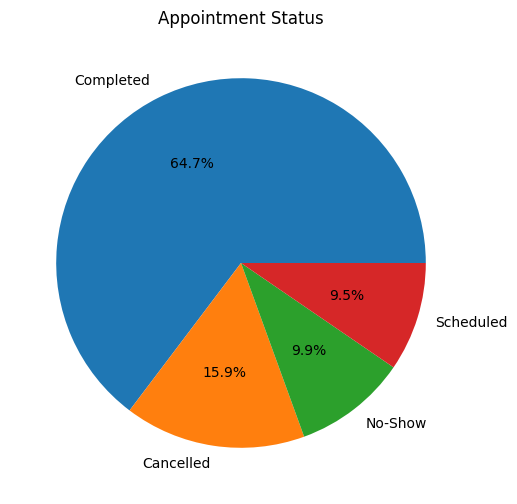

In [34]:
# appointment status
apt['status'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Appointment Status')
plt.ylabel('')
plt.show()

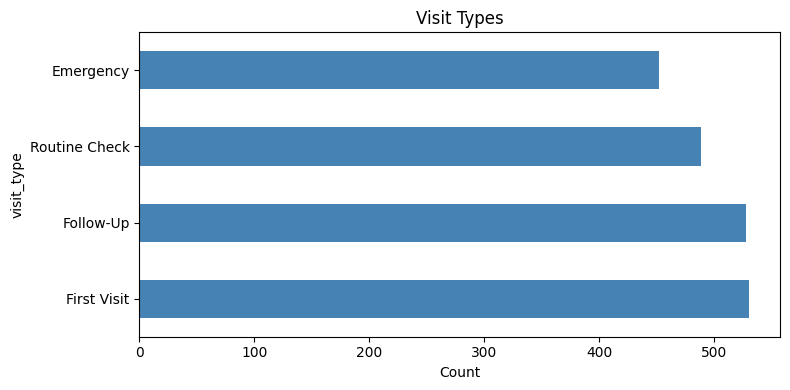

In [35]:
# visit types
apt['visit_type'].value_counts().plot(kind='barh', figsize=(8,4), color='steelblue')
plt.title('Visit Types')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

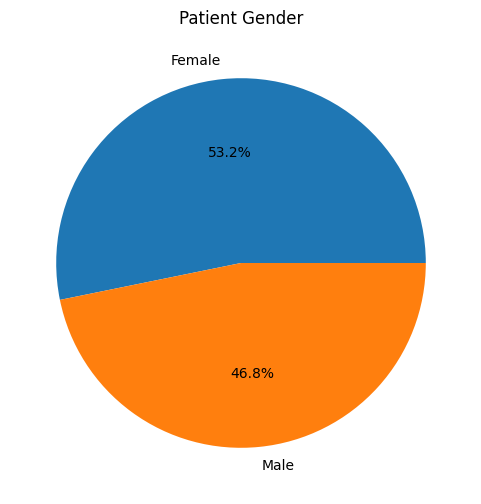

In [36]:
# gender distribution
pat['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Patient Gender')
plt.ylabel('')
plt.show()

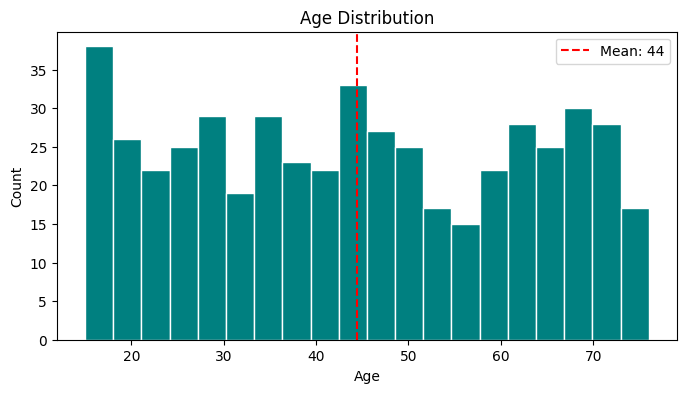

In [37]:
# age distribution
plt.figure(figsize=(8,4))
plt.hist(pat['age'], bins=20, color='teal', edgecolor='white')
plt.axvline(pat['age'].mean(), color='red', linestyle='--', label=f'Mean: {pat["age"].mean():.0f}')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

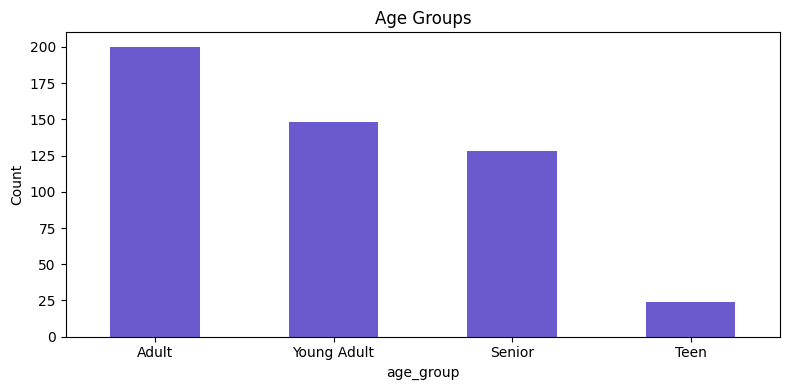

In [38]:
# age groups
pat['age_group'].value_counts().plot(kind='bar', figsize=(8,4), color='slateblue')
plt.title('Age Groups')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

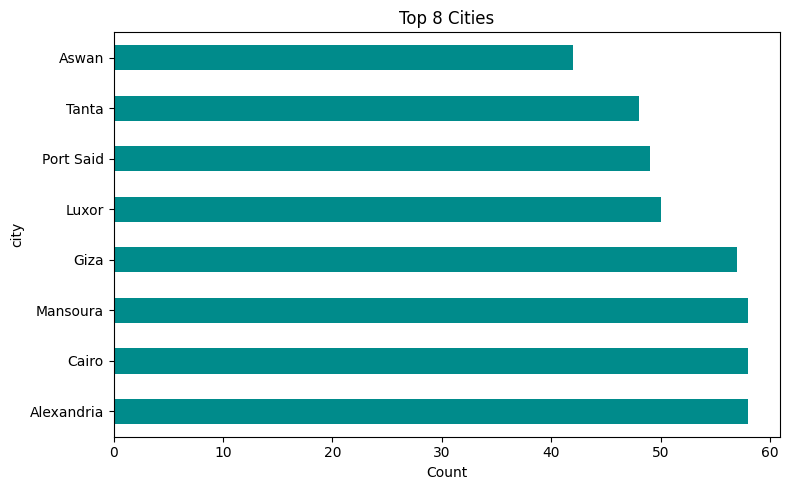

In [39]:
# top cities
pat['city'].value_counts().head(8).plot(kind='barh', figsize=(8,5), color='darkcyan')
plt.title('Top 8 Cities')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

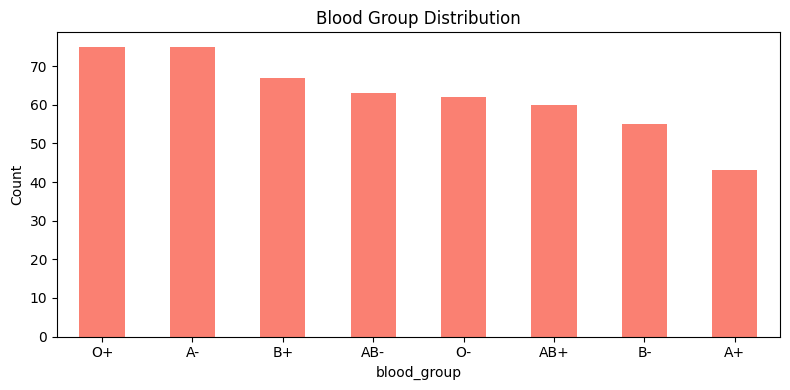

In [40]:
# blood groups
pat['blood_group'].value_counts().plot(kind='bar', figsize=(8,4), color='salmon')
plt.title('Blood Group Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

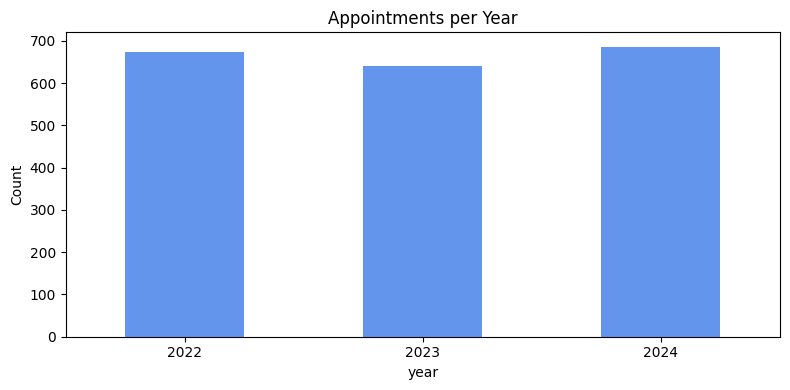

In [41]:
# appointments per year
apt['year'].value_counts().sort_index().plot(kind='bar', figsize=(8,4), color='cornflowerblue')
plt.title('Appointments per Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

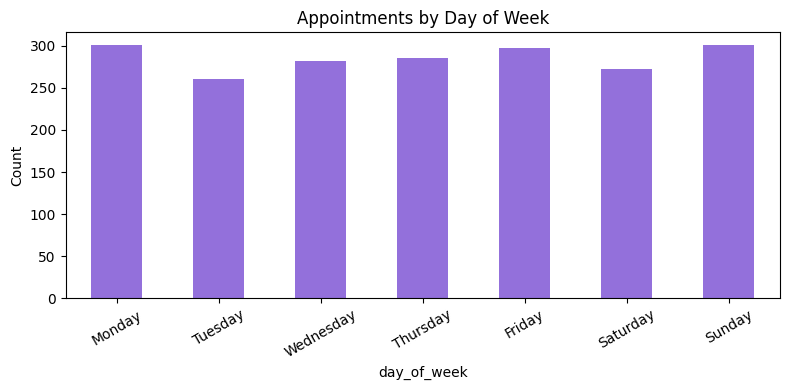

In [42]:
# appointments per day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
apt['day_of_week'].value_counts().reindex(day_order).plot(kind='bar', figsize=(8,4), color='mediumpurple')
plt.title('Appointments by Day of Week')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

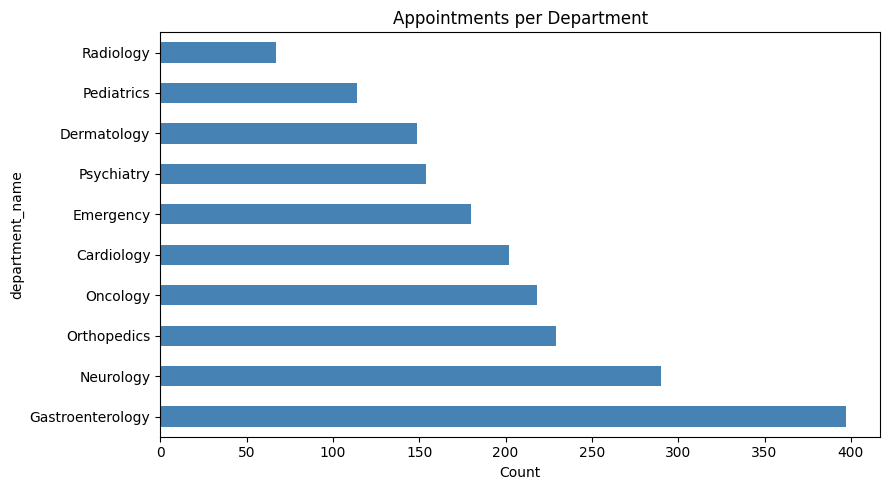

In [43]:
# appointments and revenue per department
dept_stats = master.groupby('department_name').agg(
    appointments=('appointment_id', 'count'),
    revenue=('fee_paid', 'sum')
).sort_values('appointments', ascending=False)

dept_stats['appointments'].plot(kind='barh', figsize=(9,5), color='steelblue')
plt.title('Appointments per Department')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

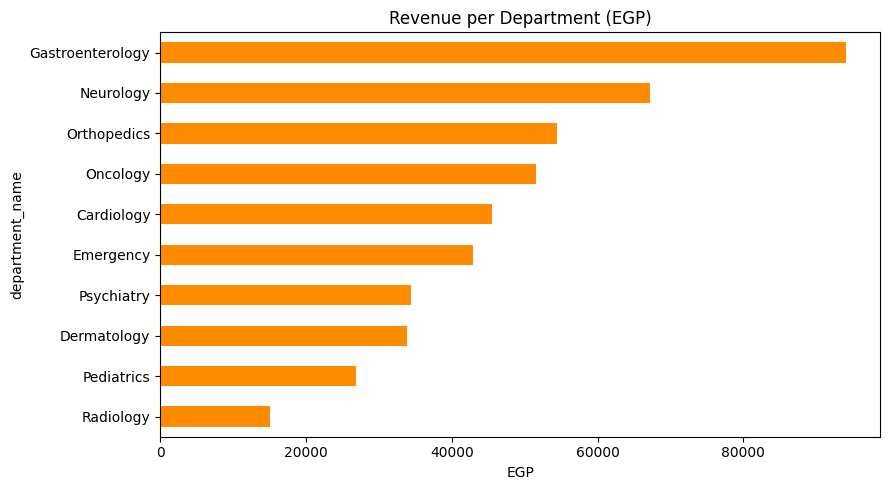

In [44]:
dept_stats['revenue'].sort_values().plot(kind='barh', figsize=(9,5), color='darkorange')
plt.title('Revenue per Department (EGP)')
plt.xlabel('EGP')
plt.tight_layout()
plt.show()

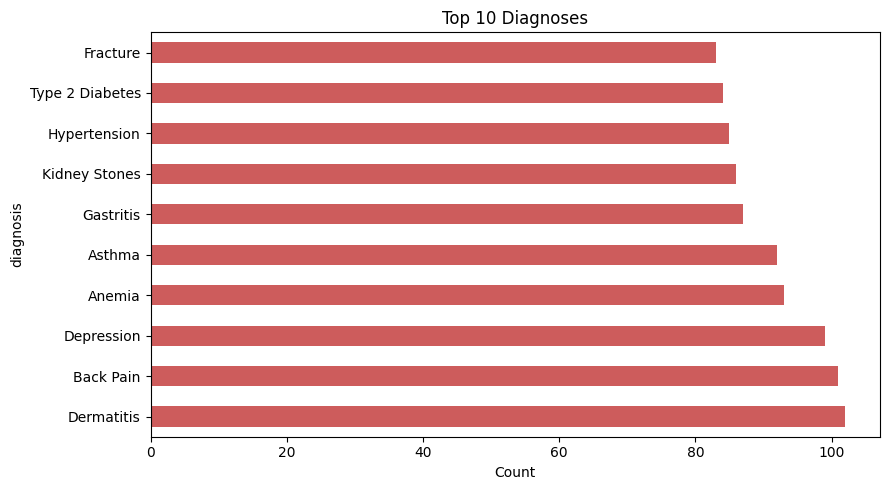

In [45]:
# top diagnoses
med['diagnosis'].value_counts().head(10).plot(kind='barh', figsize=(9,5), color='indianred')
plt.title('Top 10 Diagnoses')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

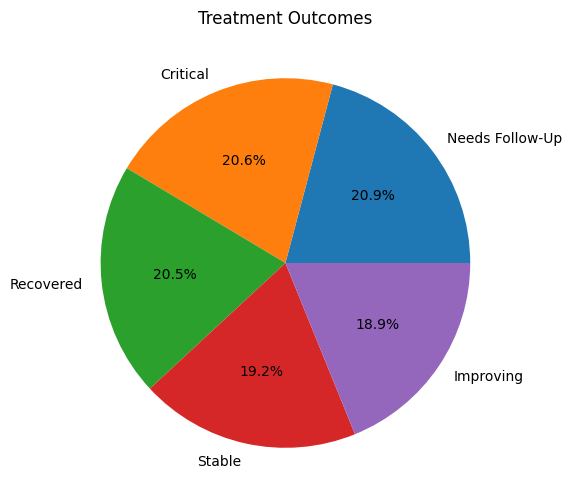

In [46]:
# treatment outcomes
med['outcome'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Treatment Outcomes')
plt.ylabel('')
plt.show()

In [47]:
# treatment duration
plt.figure(figsize=(8,4))
plt.hist(med['duration_days'], bins=20, color='seagreen', edgecolor='white')
plt.axvline(med['duration_days'].mean(), color='red', linestyle='--',
            label=f'Mean: {med["duration_days"].mean():.1f} days')
plt.title('Treatment Duration (days)')
plt.xlabel('Days')
plt.ylabel('Count')
plt.legend()
plt.show()

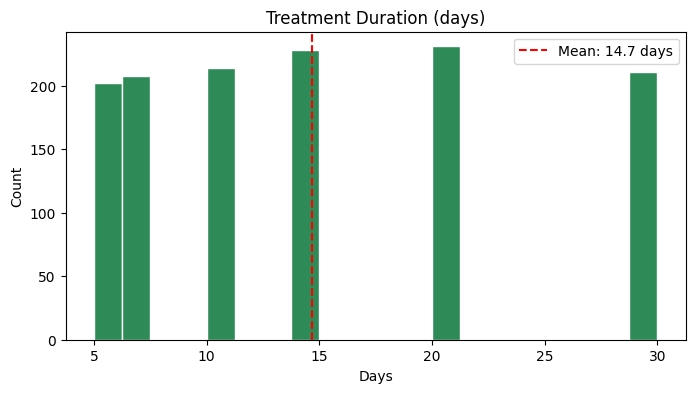

In [48]:
# experience levels
doc['experience_level'].value_counts().plot(kind='bar', figsize=(7,4), color='cadetblue')
plt.title('Doctor Experience Levels')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

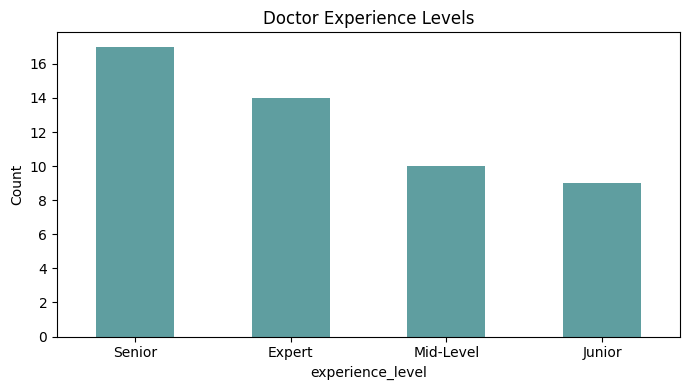

In [49]:
# fee category
apt['fee_category'].value_counts().plot(kind='bar', figsize=(7,4), color='goldenrod')
plt.title('Fee Category Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

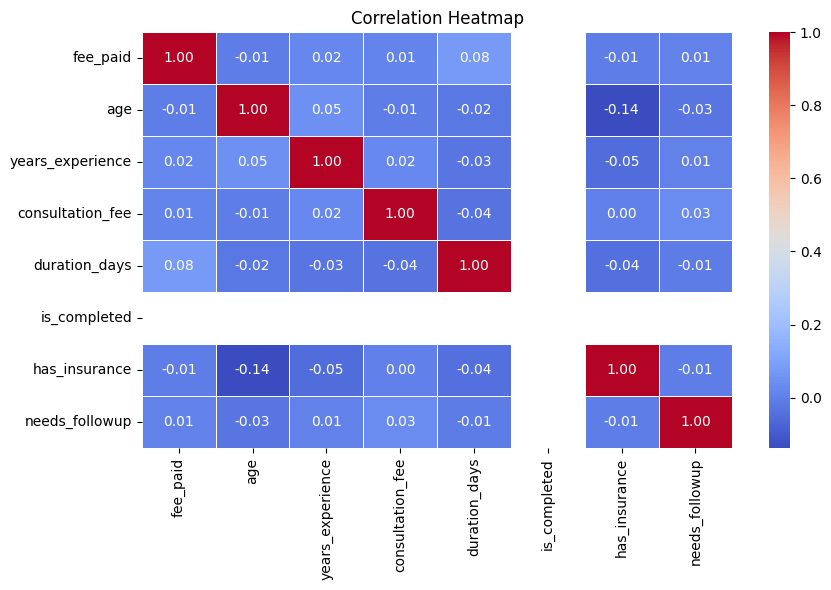

In [50]:
# correlation heatmap
num_cols = ['fee_paid', 'age', 'years_experience', 'consultation_fee',
            'duration_days', 'is_completed', 'has_insurance', 'needs_followup']

plt.figure(figsize=(9,6))
sns.heatmap(master[num_cols].dropna().corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

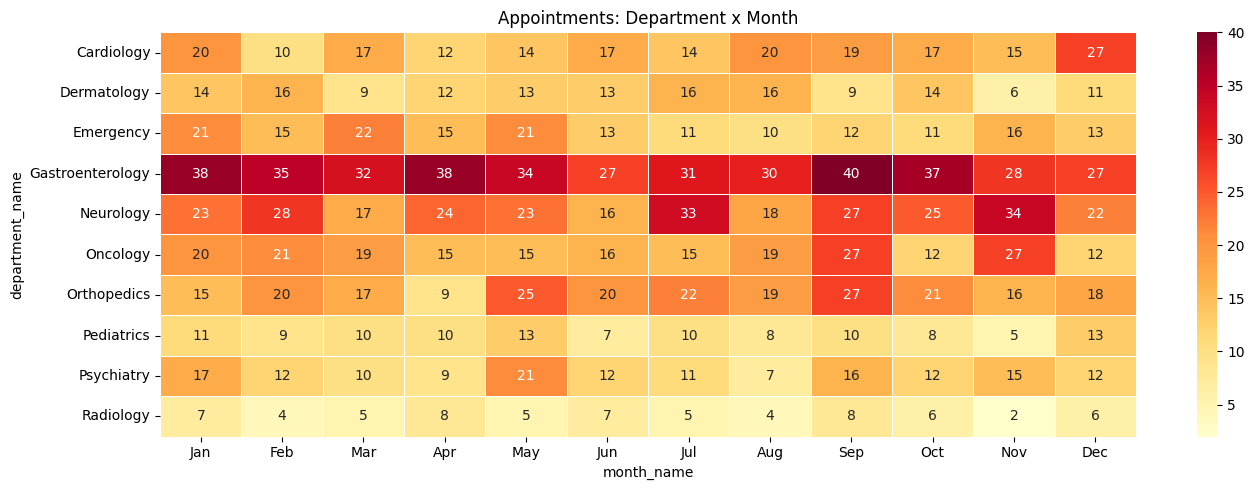

In [51]:
# department x month heatmap
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

pivot = master.groupby(['department_name','month_name']).size().unstack().fillna(0)
pivot = pivot.reindex(columns=[m for m in month_order if m in pivot.columns])

plt.figure(figsize=(14,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.4)
plt.title('Appointments: Department x Month')
plt.tight_layout()
plt.show()

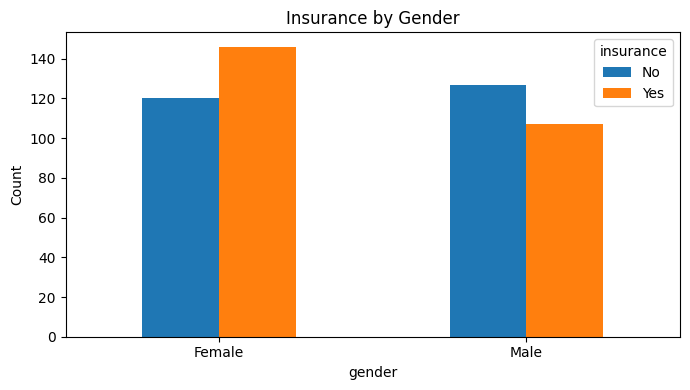

In [52]:
# insurance by gender
pat.groupby(['gender','insurance']).size().unstack().plot(kind='bar', figsize=(7,4))
plt.title('Insurance by Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [53]:
# export master table
master.to_csv('master_hospital_data.csv', index=False)
print('Done - master_hospital_data.csv saved')
master.shape

Done - master_hospital_data.csv saved


(2000, 35)